<a href="https://colab.research.google.com/github/PawaniMekhala/AI-Driven-Student-Dropout-Prediction/blob/main/02_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

data_path = "/content/drive/MyDrive/student-dropout-prediction/data/raw/data.csv"
# Load dataset
df = pd.read_csv(data_path, sep=';')
print(df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(4424, 37)


In [ ]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [ ]:
df.columns = df.columns.str.replace('\t','', regex=True)
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

In [ ]:
# Convert Target to binary (Dropout = 1)
df['Dropout'] = df['Target'].apply(
    lambda x: 1 if x == 'Dropout' else 0
    )
# check if Convert Target to binary or not (Dropout = 1)
df[['Target', 'Dropout']].head()
df['Dropout'].value_counts()

,count
Dropout,
0,3003
1,1421


In [ ]:
# REMOVE second-semester column
drop_cols = [
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)'
]

df = df.drop(columns=drop_cols)
# to check if successfully removed second-semester columns or not
df.shape

(4424, 32)

In [ ]:
# Drop original Target column and Keep only binary target
df = df.drop(columns=['Target'])


In [ ]:
# Identify Categorical & Numeric Features
categorical_cols = [
    'Marital status',
    'Application mode',
    'Application order',
    'Course',
    'Daytime/evening attendance',
    'Previous qualification',
    'Nacionality',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Displaced',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'International'
]

# Manually define numeric columns
numeric_cols = [
    'Age at enrollment',
    'Previous qualification (grade)',
    'Admission grade',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

# Print to verify
print("Categorical columns:", len(categorical_cols))
print("Numeric columns:", len(numeric_cols))


Categorical columns: 18
Numeric columns: 12


In [ ]:
# Separate FEATURES (X) and TARGET (y)
X = df.drop(columns=['Dropout'])
y = df['Dropout']

# to check if Separate FEATURES (X) and TARGET (y)
X.shape, y.shape

((4424, 30), (4424,))

In [ ]:
from sklearn.model_selection import train_test_split

# Train–Test Split FIRST (before encoding)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(3539, 30) (885, 30)


In [ ]:
# One-hot encode TRAIN set (fit)
X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=True
)

#  One-hot encode TEST set (transform)
X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=True
)

# Align columns (CRITICAL STEP)
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join='left',
    axis=1,
    fill_value=0
)

print(X_train_encoded.shape, X_test_encoded.shape)


(3539, 226) (885, 226)


In [ ]:
# Check for near-zero variance features
low_variance_features = [
    col for col in X_train_encoded.columns
    if X_train_encoded[col].var() < 0.01
]

print("Number of near-zero variance features:",
      len(low_variance_features))

# Optional: show first few features
print(low_variance_features[:10])

Number of near-zero variance features: 138
['Marital status_3', 'Marital status_5', 'Marital status_6', 'Application mode_2', 'Application mode_5', 'Application mode_10', 'Application mode_15', 'Application mode_16', 'Application mode_26', 'Application mode_27']


In [ ]:
# Save processed Train & Test Sets

PROJECT_ROOT = "/content/drive/MyDrive/student-dropout-prediction"

X_train_encoded.to_csv(
    f"{PROJECT_ROOT}/data/processed/X_train.csv",
    index=False
)

y_train.to_csv(
    f"{PROJECT_ROOT}/data/processed/y_train.csv",
    index=False
)


X_test_encoded.to_csv(
    f"{PROJECT_ROOT}/data/processed/X_test.csv",
    index=False
)

y_test.to_csv(
    f"{PROJECT_ROOT}/data/processed/y_test.csv",
    index=False
)

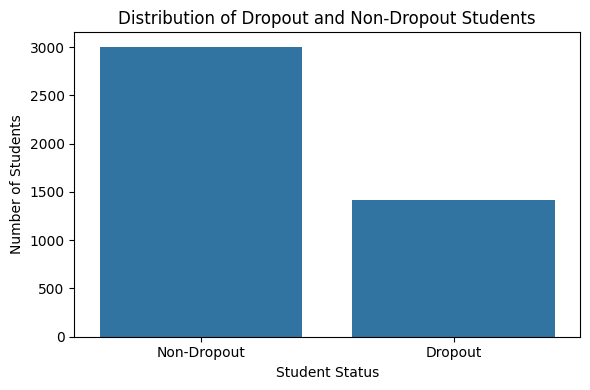

In [ ]:
# Dropout vs Non-Dropout Distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Dropout', data=df)
plt.xticks([0,1], ['Non-Dropout', 'Dropout'])
plt.xlabel('Student Status')
plt.ylabel('Number of Students')
plt.title('Distribution of Dropout and Non-Dropout Students')
plt.tight_layout()
plt.show()


In [ ]:
print(df.columns)

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)', 'Unemployment rate',
       'Inflation rate', 'GDP', 'Dropout'],
      dtype='object')


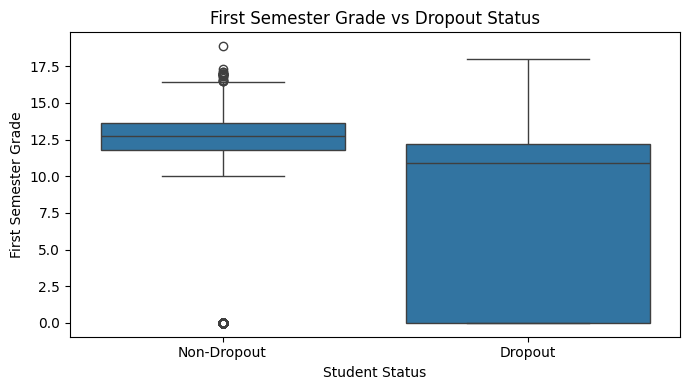

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(x='Dropout', y='Curricular units 1st sem (grade)', data=df)
plt.xticks([0,1], ['Non-Dropout', 'Dropout'])
plt.xlabel('Student Status')
plt.ylabel('First Semester Grade')
plt.title('First Semester Grade vs Dropout Status')
plt.tight_layout()
plt.show()
